## METHOD 1 ##

Adding a new regression head to the papagei model

In [1]:
import torch
import os
import re
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import h5py
from tqdm import tqdm

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib
matplotlib.use("Agg")

import sys
sys.path.append("/data1/yashvi_bhuva/anemia/PPG_BP/PaPaGei/papagei-foundation-model")
import pyPPG.preproc as PP
from dotmap import DotMap
from linearprobing.utils import resample_batch_signal, load_model_without_module_prefix
from models.resnet import ResNet1DMoE

/home/yashvi_bhuva/.local/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [5]:
RAW_DIR = "/data1/yashvi_bhuva/anemia/PPG_BP/ppg_data"             # folder of raw .txt files, e.g. "2_1.txt"
FS_ORIGINAL = 1000                 # PPG-BP native sampling rate — confirm
FS_TARGET_PAPAGEI = 125            # PaPaGei-S expected input rate
WEIGHTS_PATH = "papagei-foundation-model/weights/papagei_s.pt"
METADATA_PATH = "/data1/yashvi_bhuva/anemia/PPG_BP/PPG-BP dataset.xlsx"

In [6]:
# Loading the PaPaGei model
model_config = {
    'base_filters': 32, 'kernel_size': 3, 'stride': 2, 'groups': 1,
    'n_block': 18, 'n_classes': 512, 'n_experts': 3
}
papagei = ResNet1DMoE(in_channels=1, **model_config)
papagei = load_model_without_module_prefix(papagei, WEIGHTS_PATH)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
papagei.to(device).eval()

cuda


ResNet1DMoE(
  (first_block_conv): MyConv1dPadSame(
    (conv): Conv1d(1, 32, kernel_size=(3,), stride=(1,))
  )
  (first_block_bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (first_block_relu): ReLU()
  (basicblock_list): ModuleList(
    (0): BasicBlock(
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu1): ReLU()
      (do1): Dropout(p=0.5, inplace=False)
      (conv1): MyConv1dPadSame(
        (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
      )
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu2): ReLU()
      (do2): Dropout(p=0.5, inplace=False)
      (conv2): MyConv1dPadSame(
        (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
      )
      (max_pool): MyMaxPool1dPadSame(
        (max_pool): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
      )
    )
    

In [7]:
#Freezeall the layer weights
for param in papagei.parameters():
    param.requires_grad = False

sum(p.requires_grad for p in papagei.parameters())

0

In [8]:
x = torch.randn(2,1,625).to(device)

with torch.no_grad():
    y = papagei(x)

print(type(y))

if isinstance(y, tuple):
    print(len(y))
    for i,v in enumerate(y):
        print(i, v.shape)
else:
    print(y.shape)

<class 'tuple'>
4
0 torch.Size([2, 512])
1 torch.Size([2, 1])
2 torch.Size([2, 1])
3 torch.Size([2, 512])


In [9]:
class BPModel(nn.Module):

    def __init__(self, papagei):

        super().__init__()

        self.encoder = papagei

        self.regressor = nn.Sequential(

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 2)      # SBP, DBP

        )

    def forward(self, x):

        outputs = self.encoder(x)

        embedding = outputs[0]      # (batch,512)

        prediction = self.regressor(embedding)

        return prediction

In [10]:
def preprocess_one_ppg_signal(waveform, frequency, fL=0.5, fH=12, order=4,
                                smoothing_windows={"ppg": 50, "vpg": 10, "apg": 10, "jpg": 10}):
    prep = PP.Preprocess(fL=fL, fH=fH, order=order, sm_wins=smoothing_windows)
    signal = DotMap()
    signal.v = waveform
    signal.fs = frequency
    signal.filtering = True
    ppg, ppg_d1, ppg_d2, ppg_d3 = prep.get_signals(signal)
    return ppg, ppg_d1, ppg_d2, ppg_d3


def is_signal_flat_lined_simple(sig, fs, flat_threshold=0.25, change_threshold=0.01, window_ms=20):
    sig = np.asarray(sig, dtype=float)
    sig_norm = (sig - np.mean(sig)) / (np.std(sig) + 1e-8)

    step = max(1, int(fs * window_ms / 1000))  # compare samples ~20ms apart, not adjacent
    diffs = np.abs(sig_norm[step:] - sig_norm[:-step])
    flat_fraction = np.sum(diffs < change_threshold) / len(diffs)
    return 1 if flat_fraction > flat_threshold else 0

In [11]:
signals = []

sbp_labels = []
dbp_labels = []

subject_ids = []
segments = []

filenames = []

In [12]:
fname_pattern = re.compile(r"^(\d+)_(\d+)")

meta = pd.read_excel(METADATA_PATH, sheet_name="cardiovascular dataset", header=1)
meta["subject_ID"] = meta["subject_ID"].astype(int)
meta = meta.set_index("subject_ID")
for file in tqdm(os.listdir(RAW_DIR)):

    try:

        match = fname_pattern.match(file)

        if match is None:
            continue

        subject_id = int(match.group(1))
        segment = int(match.group(2))

        if subject_id not in meta.index:
            continue

        ##################################################
        # Load raw signal
        ##################################################

        raw_ppg = np.loadtxt(
            os.path.join(RAW_DIR, file)
        )

        ##################################################
        # Filter
        ##################################################

        ppg_filt, _, _, _ = preprocess_one_ppg_signal(
            waveform=raw_ppg,
            frequency=FS_ORIGINAL
        )

        ##################################################
        # Quality check
        ##################################################

        if is_signal_flat_lined_simple(
            ppg_filt,
            fs=FS_ORIGINAL
        ):
            continue

        ##################################################
        # Resample
        ##################################################

        resampled = resample_batch_signal(
            ppg_filt[np.newaxis, :],
            fs_original=FS_ORIGINAL,
            fs_target=FS_TARGET_PAPAGEI,
            axis=-1
        ).squeeze()

        ##################################################
        # Labels
        ##################################################

        row = meta.loc[subject_id]

        signals.append(resampled.astype(np.float32))

        sbp_labels.append(
            row["Systolic Blood Pressure(mmHg)"]
        )

        dbp_labels.append(
            row["Diastolic Blood Pressure(mmHg)"]
        )

        subject_ids.append(subject_id)

        segments.append(segment)

        filenames.append(file)

    except Exception as e:

        print(file, e)

100%|██████████| 657/657 [00:03<00:00, 172.61it/s]


In [13]:
MAX_LEN = 525

signals_padded = []

for sig in signals:
    if len(sig) < MAX_LEN:
        pad = MAX_LEN - len(sig)
        sig = np.pad(sig, (0, pad), mode="edge") # Edge padding to avoid introducing new values and it produces a more natural continuation of the signal
    signals_padded.append(sig.astype(np.float32))

signals = np.stack(signals_padded)

In [14]:
signals = np.stack(signals)

sbp_labels = np.array(sbp_labels)

dbp_labels = np.array(dbp_labels)

subject_ids = np.array(subject_ids)

segments = np.array(segments)

filenames = np.array(filenames, dtype="S")

In [15]:
data = pd.DataFrame({
    "signal_idx": np.arange(len(signals)),
    "SBP": sbp_labels,
    "DBP": dbp_labels,
    "subject_id": subject_ids,
    "segment": segments,
    "file": filenames
})

print(data.head())
print(data.shape)

   signal_idx  SBP  DBP  subject_id  segment          file
0           0  130   66         105        1  b'105_1.txt'
1           1  141   67         139        2  b'139_2.txt'
2           2  150   96          38        2   b'38_2.txt'
3           3  149   71         138        2  b'138_2.txt'
4           4  102   55         405        1  b'405_1.txt'
(657, 6)


In [16]:
#Subject-wise split of data into train and test sets to avoid data leakage
from sklearn.model_selection import GroupShuffleSplit


# First split: train + temp(test+val)
splitter1 = GroupShuffleSplit(
    test_size=0.3,
    random_state=42
)


train_idx, temp_idx = next(
    splitter1.split(
        data,
        groups=data["subject_id"]
    )
)


train_df = data.iloc[train_idx].reset_index(drop=True)
temp_df = data.iloc[temp_idx].reset_index(drop=True)



# Second split: validation + test
splitter2 = GroupShuffleSplit(
    test_size=0.5,
    random_state=42
)


val_idx, test_idx = next(
    splitter2.split(
        temp_df,
        groups=temp_df["subject_id"]
    )
)


val_df = temp_df.iloc[val_idx].reset_index(drop=True)

test_df = temp_df.iloc[test_idx].reset_index(drop=True)



print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


print("\nSubjects:")
print("Train:", train_df.subject_id.nunique())
print("Val:", val_df.subject_id.nunique())
print("Test:", test_df.subject_id.nunique())

Train: 459
Validation: 99
Test: 99

Subjects:
Train: 153
Val: 33
Test: 33


In [17]:
class PPGDataset(Dataset):

    def __init__(self, dataframe, signals):

        self.df = dataframe.reset_index(drop=True)
        self.signals = signals


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        signal_idx = row.signal_idx


        # Already filtered, resampled, padded
        signal = self.signals[signal_idx]


        # Papagei expects channel dimension
        signal = torch.tensor(
            signal,
            dtype=torch.float32
        ).unsqueeze(0)


        target = torch.tensor(
            [
                row.SBP,
                row.DBP
            ],
            dtype=torch.float32
        )


        return signal, target

In [18]:
train_dataset = PPGDataset(
    train_df,
    signals
)

val_dataset = PPGDataset(
    val_df,
    signals
)
test_dataset = PPGDataset(
    test_df,
    signals
)


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [19]:
#To verify that there is no data leakage between train, validation and test sets, we can check the number of common subjects between them. If the number is zero, it means there is no data leakage.
print(
    len(
        set(train_df.subject_id)
        &
        set(test_df.subject_id)
    )
)

print(
    len(
        set(train_df.subject_id)
        &
        set(val_df.subject_id)
    )
)

0
0


In [20]:
x, y = next(iter(train_loader))

print("Input shape:", x.shape)
print("Target shape:", y.shape)

print("Signal range:", x.min(), x.max())
print("Labels:", y[:5])

Input shape: torch.Size([32, 1, 525])
Target shape: torch.Size([32, 2])
Signal range: tensor(-573.4620) tensor(968.3157)
Labels: tensor([[158.,  89.],
        [130.,  66.],
        [113.,  55.],
        [139.,  84.],
        [106.,  63.]])


In [21]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# move one batch to device
x = x.to(device)

# load only the encoder part
papagei = papagei.to(device)
papagei.eval()

with torch.no_grad():

    outputs = papagei(x)


print("Output type:", type(outputs))


if isinstance(outputs, tuple):
    print("Number of outputs:", len(outputs))
    print("First output shape:", outputs[0].shape)

else:
    print("Output shape:", outputs.shape)

Output type: <class 'tuple'>
Number of outputs: 4
First output shape: torch.Size([32, 512])


In [22]:
model = BPModel(papagei)

model = model.to(device)

print(model)

BPModel(
  (encoder): ResNet1DMoE(
    (first_block_conv): MyConv1dPadSame(
      (conv): Conv1d(1, 32, kernel_size=(3,), stride=(1,))
    )
    (first_block_bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (first_block_relu): ReLU()
    (basicblock_list): ModuleList(
      (0): BasicBlock(
        (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU()
        (do1): Dropout(p=0.5, inplace=False)
        (conv1): MyConv1dPadSame(
          (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
        )
        (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU()
        (do2): Dropout(p=0.5, inplace=False)
        (conv2): MyConv1dPadSame(
          (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
        )
        (max_pool): MyMaxPool1dPadSame(
          (max_pool): MaxPool1d(kernel_size=1, stri

In [23]:
for name, param in model.named_parameters():

    if param.requires_grad:
        print(name)

regressor.0.weight
regressor.0.bias
regressor.3.weight
regressor.3.bias
regressor.6.weight
regressor.6.bias


In [24]:
total = 0
trainable = 0

for p in model.parameters():

    total += p.numel()

    if p.requires_grad:
        trainable += p.numel()

print("Total parameters :", total)
print("Trainable parameters :", trainable)


Total parameters : 5950094
Trainable parameters : 164482


In [25]:
with torch.no_grad():

    pred = model(x)


print("Prediction shape:", pred.shape)

Prediction shape: torch.Size([32, 2])


In [26]:
import torch.optim as optim

criterion = nn.SmoothL1Loss()


optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

In [27]:
import matplotlib.pyplot as plt

epochs = 100

best_val_loss = float("inf")

train_losses = []
val_losses = []


for epoch in range(epochs):

    # -----------------
    # Training
    # -----------------
    model.train()

    train_loss = 0.0


    for signals, targets in train_loader:

        signals = signals.to(device)
        targets = targets.to(device)


        optimizer.zero_grad()


        predictions = model(signals)


        loss = criterion(
            predictions,
            targets
        )


        loss.backward()

        optimizer.step()


        train_loss += loss.item()



    train_loss /= len(train_loader)

    train_losses.append(train_loss)



    # -----------------
    # Validation
    # -----------------
    model.eval()

    val_loss = 0.0


    with torch.no_grad():

        for signals, targets in val_loader:

            signals = signals.to(device)
            targets = targets.to(device)


            predictions = model(signals)


            loss = criterion(
                predictions,
                targets
            )


            val_loss += loss.item()



    val_loss /= len(val_loader)

    val_losses.append(val_loss)



    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_papagei_bp_model.pth"
        )


    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )



Epoch [1/100] Train Loss: 99.2861 Val Loss: 97.9910
Epoch [2/100] Train Loss: 99.3736 Val Loss: 97.9849
Epoch [3/100] Train Loss: 99.4530 Val Loss: 97.9773
Epoch [4/100] Train Loss: 99.3381 Val Loss: 97.9715
Epoch [5/100] Train Loss: 99.2581 Val Loss: 97.9632
Epoch [6/100] Train Loss: 99.0965 Val Loss: 97.9566
Epoch [7/100] Train Loss: 99.2051 Val Loss: 97.9484
Epoch [8/100] Train Loss: 99.3933 Val Loss: 97.9401
Epoch [9/100] Train Loss: 99.4172 Val Loss: 97.9316
Epoch [10/100] Train Loss: 99.0887 Val Loss: 97.9209
Epoch [11/100] Train Loss: 99.3494 Val Loss: 97.9116
Epoch [12/100] Train Loss: 99.6296 Val Loss: 97.9020
Epoch [13/100] Train Loss: 99.1877 Val Loss: 97.8897
Epoch [14/100] Train Loss: 99.5912 Val Loss: 97.8788
Epoch [15/100] Train Loss: 99.1584 Val Loss: 97.8625
Epoch [16/100] Train Loss: 99.1867 Val Loss: 97.8572
Epoch [17/100] Train Loss: 99.4520 Val Loss: 97.8473
Epoch [18/100] Train Loss: 99.2042 Val Loss: 97.8208
Epoch [19/100] Train Loss: 99.0537 Val Loss: 97.7946
Ep

In [28]:
test_losses = []
model.eval()

test_loss = 0.0

all_preds = []
all_targets = []


with torch.no_grad():

    for signals, targets in test_loader:

        signals = signals.to(device)
        targets = targets.to(device)


        predictions = model(signals)


        loss = criterion(
            predictions,
            targets
        )


        test_loss += loss.item()


        # store predictions and labels
        all_preds.append(
            predictions.cpu()
        )

        all_targets.append(
            targets.cpu()
        )


test_loss /= len(test_loader)


all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()


print("Test Loss:", test_loss)


Test Loss: 87.21896553039551


In [29]:
if val_loss < best_val_loss:
    best_val_loss = val_loss
    torch.save(
        model.state_dict(),
        "best_papagei_bp_model.pth"
    )

print("Saved best model")

Saved best model


In [30]:
model.load_state_dict(
    torch.load("best_papagei_bp_model.pth")
)

model.eval()

BPModel(
  (encoder): ResNet1DMoE(
    (first_block_conv): MyConv1dPadSame(
      (conv): Conv1d(1, 32, kernel_size=(3,), stride=(1,))
    )
    (first_block_bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (first_block_relu): ReLU()
    (basicblock_list): ModuleList(
      (0): BasicBlock(
        (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU()
        (do1): Dropout(p=0.5, inplace=False)
        (conv1): MyConv1dPadSame(
          (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
        )
        (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU()
        (do2): Dropout(p=0.5, inplace=False)
        (conv2): MyConv1dPadSame(
          (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
        )
        (max_pool): MyMaxPool1dPadSame(
          (max_pool): MaxPool1d(kernel_size=1, stri

In [31]:
all_preds = []
all_targets = []


with torch.no_grad():

    for signals, targets in val_loader:

        signals = signals.to(device)

        preds = model(signals)


        all_preds.append(
            preds.cpu()
        )

        all_targets.append(
            targets
        )


all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


pred_sbp = all_preds[:,0]
pred_dbp = all_preds[:,1]


true_sbp = all_targets[:,0]
true_dbp = all_targets[:,1]



sbp_mae = mean_absolute_error(
    true_sbp,
    pred_sbp
)

dbp_mae = mean_absolute_error(
    true_dbp,
    pred_dbp
)



sbp_rmse = np.sqrt(
    mean_squared_error(
        true_sbp,
        pred_sbp
    )
)

dbp_rmse = np.sqrt(
    mean_squared_error(
        true_dbp,
        pred_dbp
    )
)



print("SBP MAE:", sbp_mae)
print("DBP MAE:", dbp_mae)

print("SBP RMSE:", sbp_rmse)
print("DBP RMSE:", dbp_rmse)

SBP MAE: 112.19942
DBP MAE: 60.134323
SBP RMSE: 114.75136
DBP RMSE: 62.28276


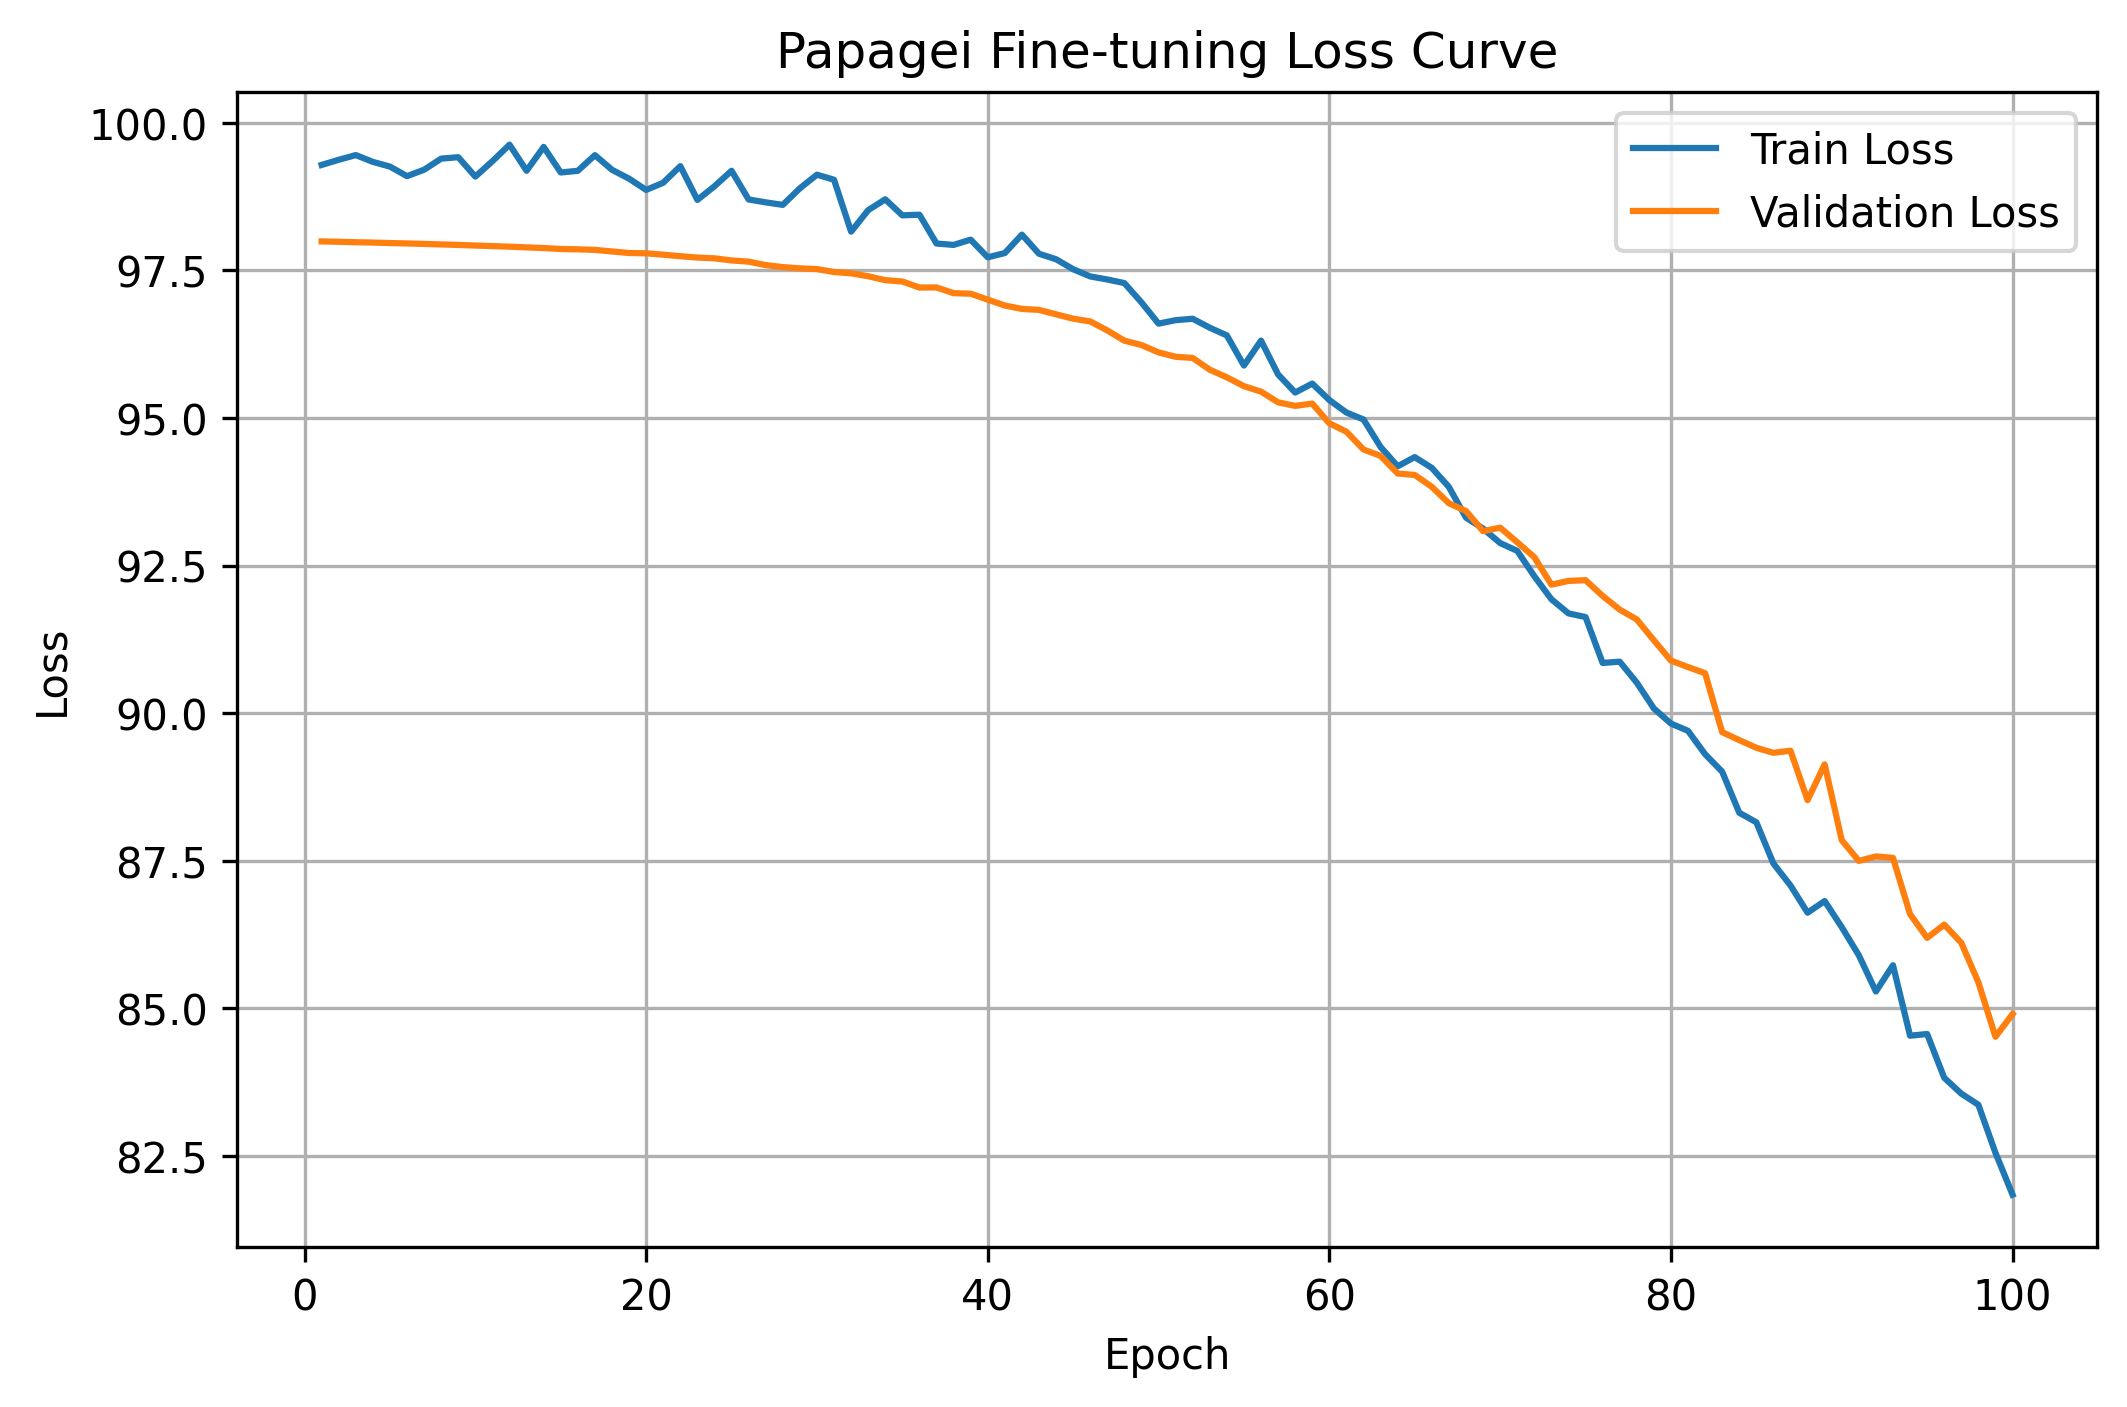

In [33]:
from IPython.display import Image, display


plt.figure(figsize=(8,5))

plt.plot(
    range(1, epochs+1),
    train_losses,
    label="Train Loss"
)

plt.plot(
    range(1, epochs+1),
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Papagei Fine-tuning Loss Curve")

plt.legend()
plt.grid(True)

plt.savefig(
    "loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


display(Image("loss_curve.png"))

## Looking at 512 embeddings (last layer of PaPaGei and it's correlation with thearget (DBP + SBP)) ##

In [34]:
model.eval()

embeddings = []
targets = []
subject_ids = []

with torch.no_grad():

    for signals, labels in train_loader:

        signals = signals.to(device)

        outputs = model.encoder(signals)

        embedding = outputs[0]      # (batch,512)

        embeddings.append(
            embedding.cpu().numpy()
        )

        targets.append(
            labels.numpy()
        )

embeddings = np.concatenate(embeddings, axis=0)
targets = np.concatenate(targets, axis=0)

print(embeddings.shape)
print(targets.shape)

(459, 512)
(459, 2)


In [35]:
from scipy.stats import pearsonr

sbp_corr = []
dbp_corr = []

for i in range(512):

    sbp_r, _ = pearsonr(
        embeddings[:,i],
        targets[:,0]
    )

    dbp_r, _ = pearsonr(
        embeddings[:,i],
        targets[:,1]
    )

    sbp_corr.append(sbp_r)
    dbp_corr.append(dbp_r)

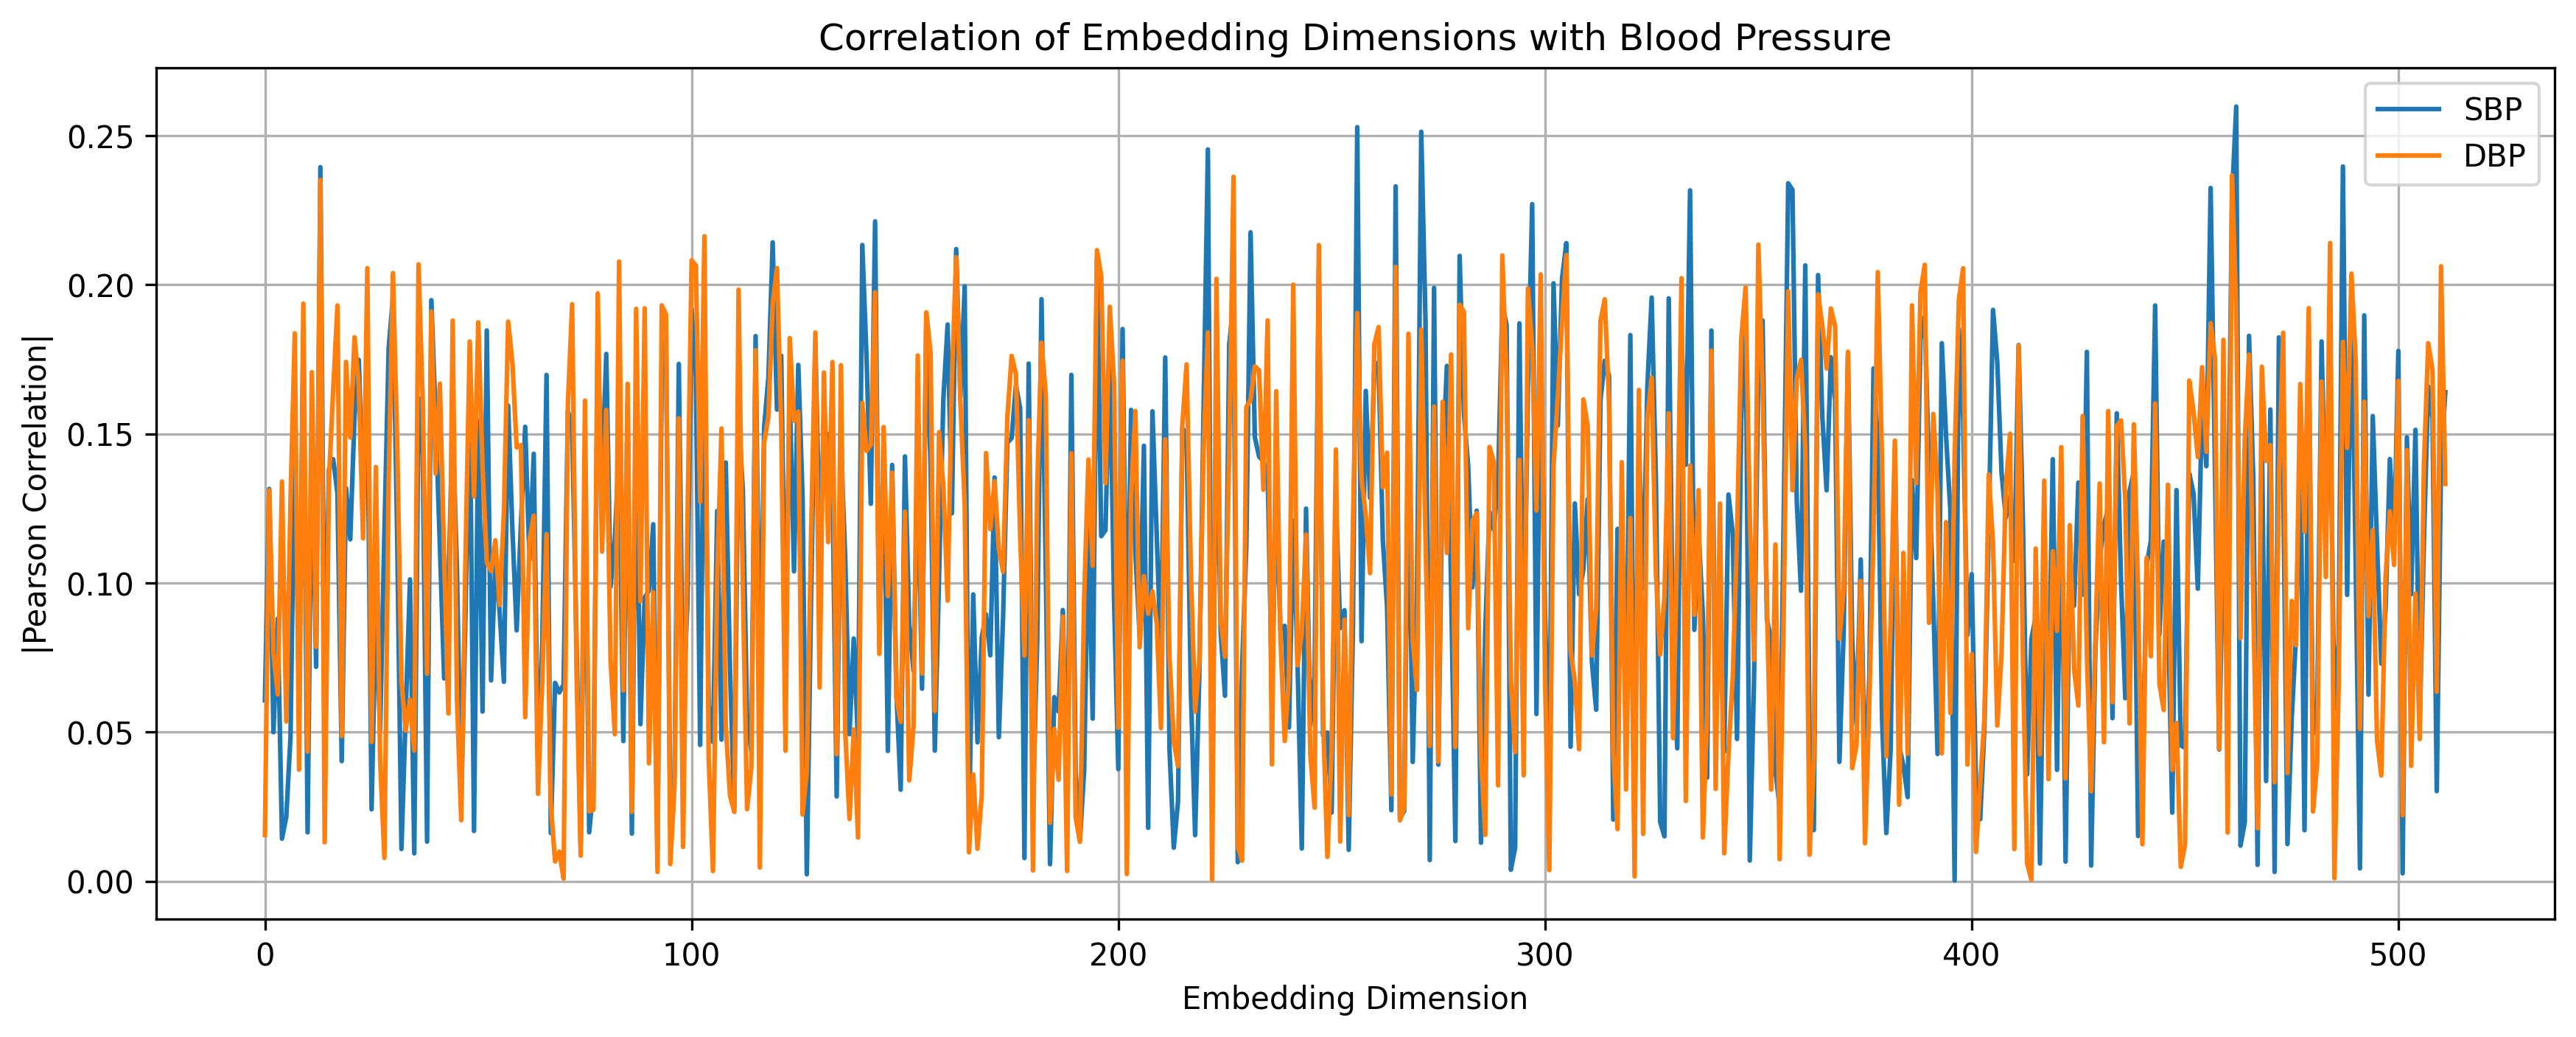

In [38]:
plt.figure(figsize=(14,5))

plt.plot(
    np.abs(sbp_corr),
    label="SBP"
)

plt.plot(
    np.abs(dbp_corr),
    label="DBP"
)

plt.xlabel("Embedding Dimension")
plt.ylabel("|Pearson Correlation|")
plt.title("Correlation of Embedding Dimensions with Blood Pressure")

plt.legend()
plt.grid(True)

plt.savefig(
    "embedding_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

display(Image("embedding_correlation.png"))

In [39]:
top_sbp = np.argsort(np.abs(sbp_corr))[::-1][:20]
top_dbp = np.argsort(np.abs(dbp_corr))[::-1][:20]

print("Top SBP dimensions")

for d in top_sbp:
    print(
        f"Dimension {d:3d} : r = {sbp_corr[d]:.3f}"
    )

print()

print("Top DBP dimensions")

for d in top_dbp:
    print(
        f"Dimension {d:3d} : r = {dbp_corr[d]:.3f}"
    )

Top SBP dimensions
Dimension 462 : r = -0.260
Dimension 256 : r = 0.253
Dimension 271 : r = -0.251
Dimension 221 : r = 0.245
Dimension 487 : r = 0.240
Dimension  13 : r = 0.239
Dimension 357 : r = -0.234
Dimension 265 : r = -0.233
Dimension 456 : r = -0.232
Dimension 358 : r = -0.232
Dimension 334 : r = -0.232
Dimension 461 : r = -0.229
Dimension 297 : r = 0.227
Dimension 143 : r = 0.221
Dimension 231 : r = -0.218
Dimension 119 : r = -0.214
Dimension 305 : r = 0.214
Dimension 140 : r = -0.213
Dimension 162 : r = 0.212
Dimension 280 : r = -0.210

Top DBP dimensions
Dimension 461 : r = -0.237
Dimension 227 : r = -0.236
Dimension  13 : r = 0.235
Dimension 103 : r = 0.216
Dimension 484 : r = 0.214
Dimension 350 : r = -0.213
Dimension 247 : r = 0.213
Dimension 195 : r = 0.212
Dimension 305 : r = 0.210
Dimension 290 : r = 0.210
Dimension 162 : r = 0.209
Dimension 100 : r = -0.208
Dimension  83 : r = 0.208
Dimension  36 : r = -0.207
Dimension 389 : r = -0.207
Dimension 101 : r = 0.206
Dimensi

## Conclusion ##

The correlation are almost equal. This means -

1. Either the information of BP is evenly spread across all  the embeddings
2. This model doesn't learn BP

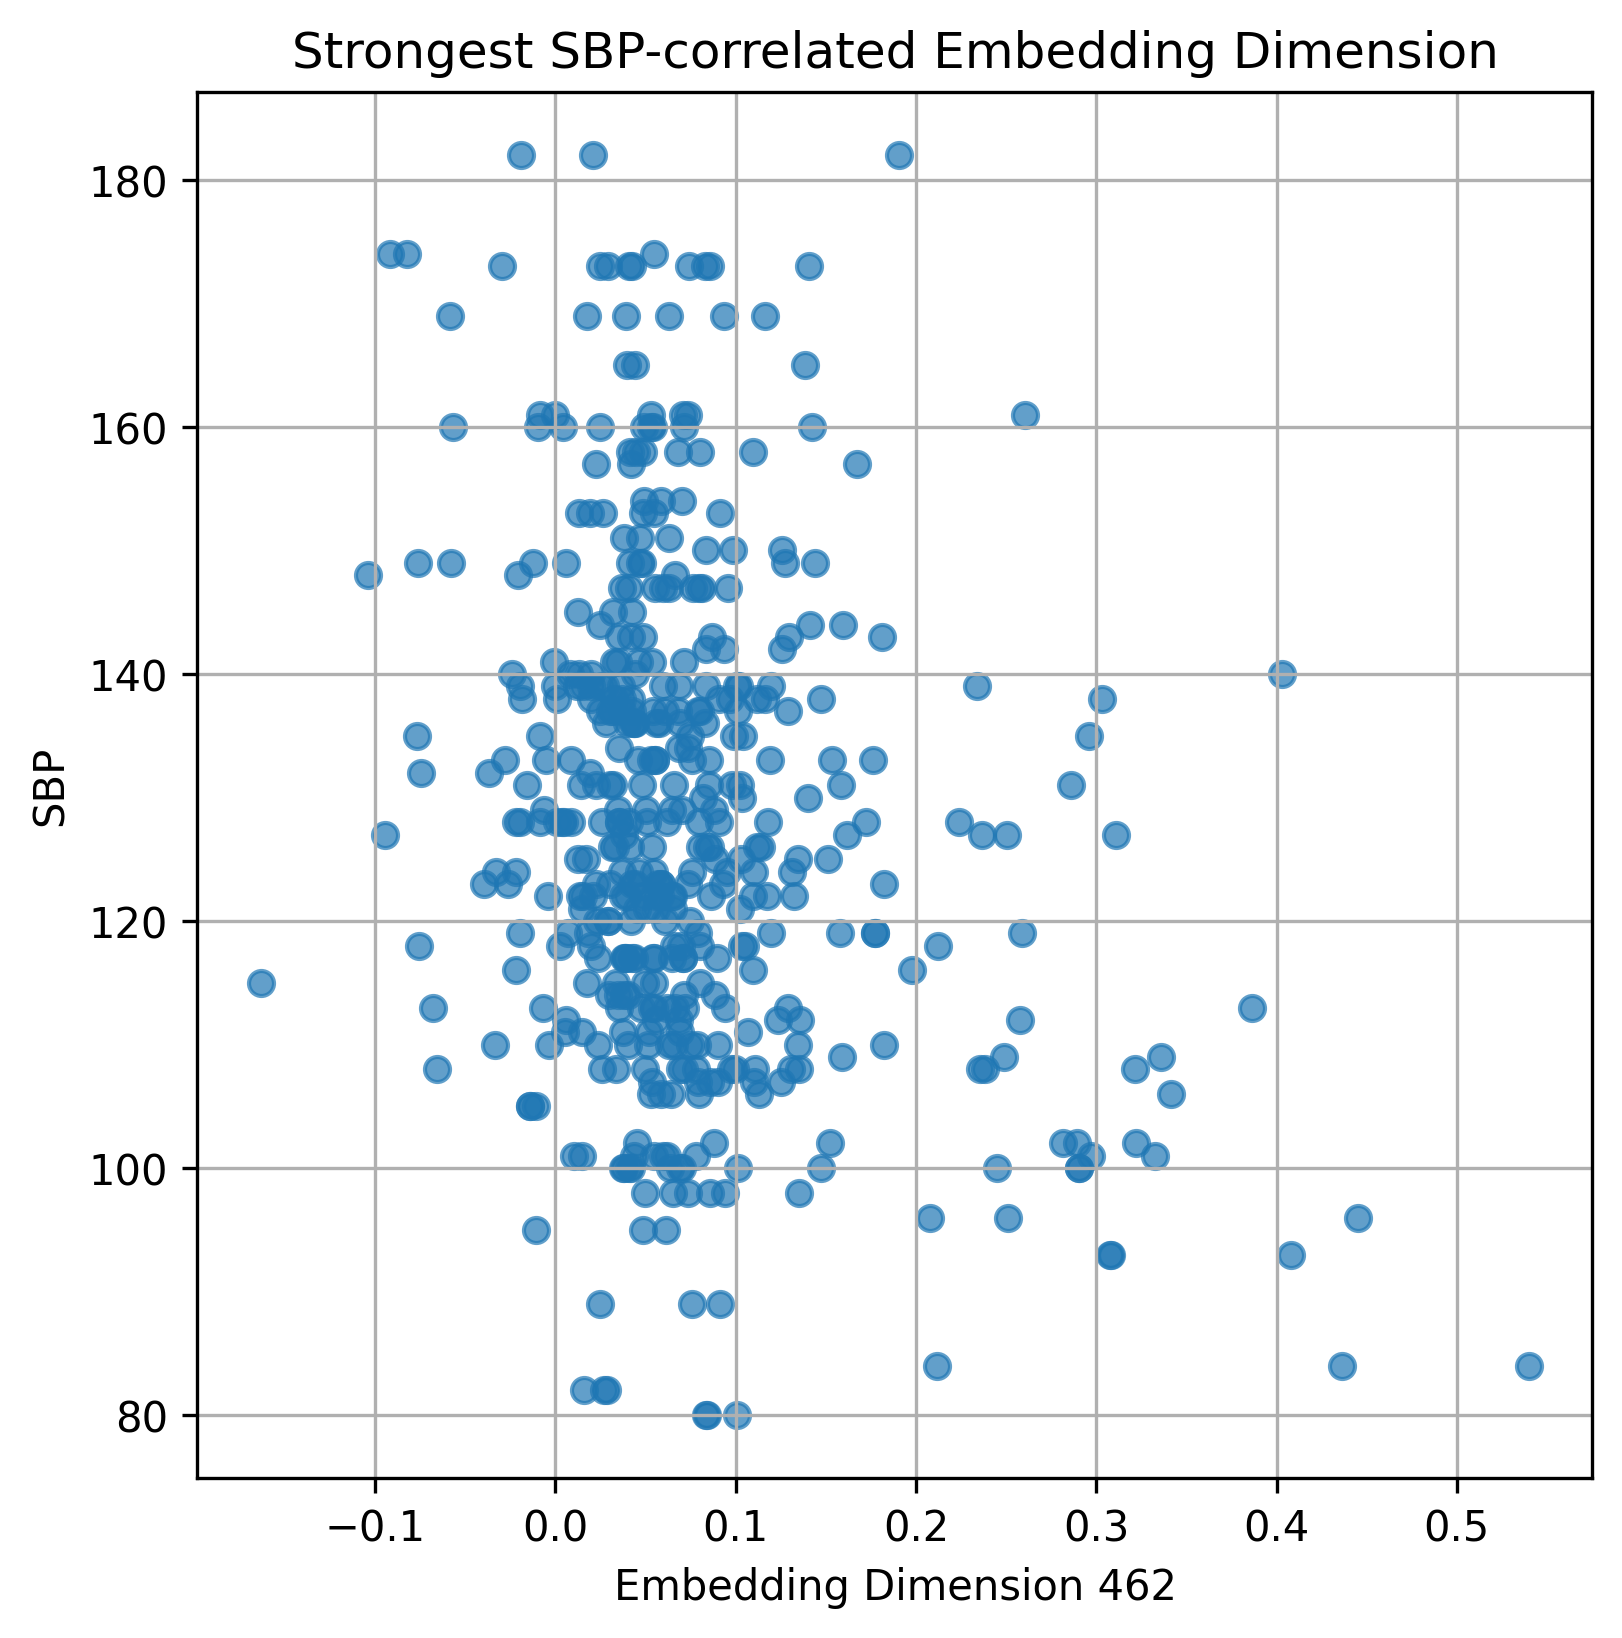

In [ ]:
best = np.argmax(np.abs(sbp_corr))

plt.figure(figsize=(6,6))

plt.scatter(
    embeddings[:, best],
    targets[:,0],
    alpha=0.7
)

plt.xlabel(f"Embedding Dimension {best} values for the recordings")
plt.ylabel("SBP")
plt.title("Strongest SBP-correlated Embedding Dimension")

plt.grid(True)

plt.savefig(
    "best_sbp_dimension.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

display(Image("best_sbp_dimension.png"))

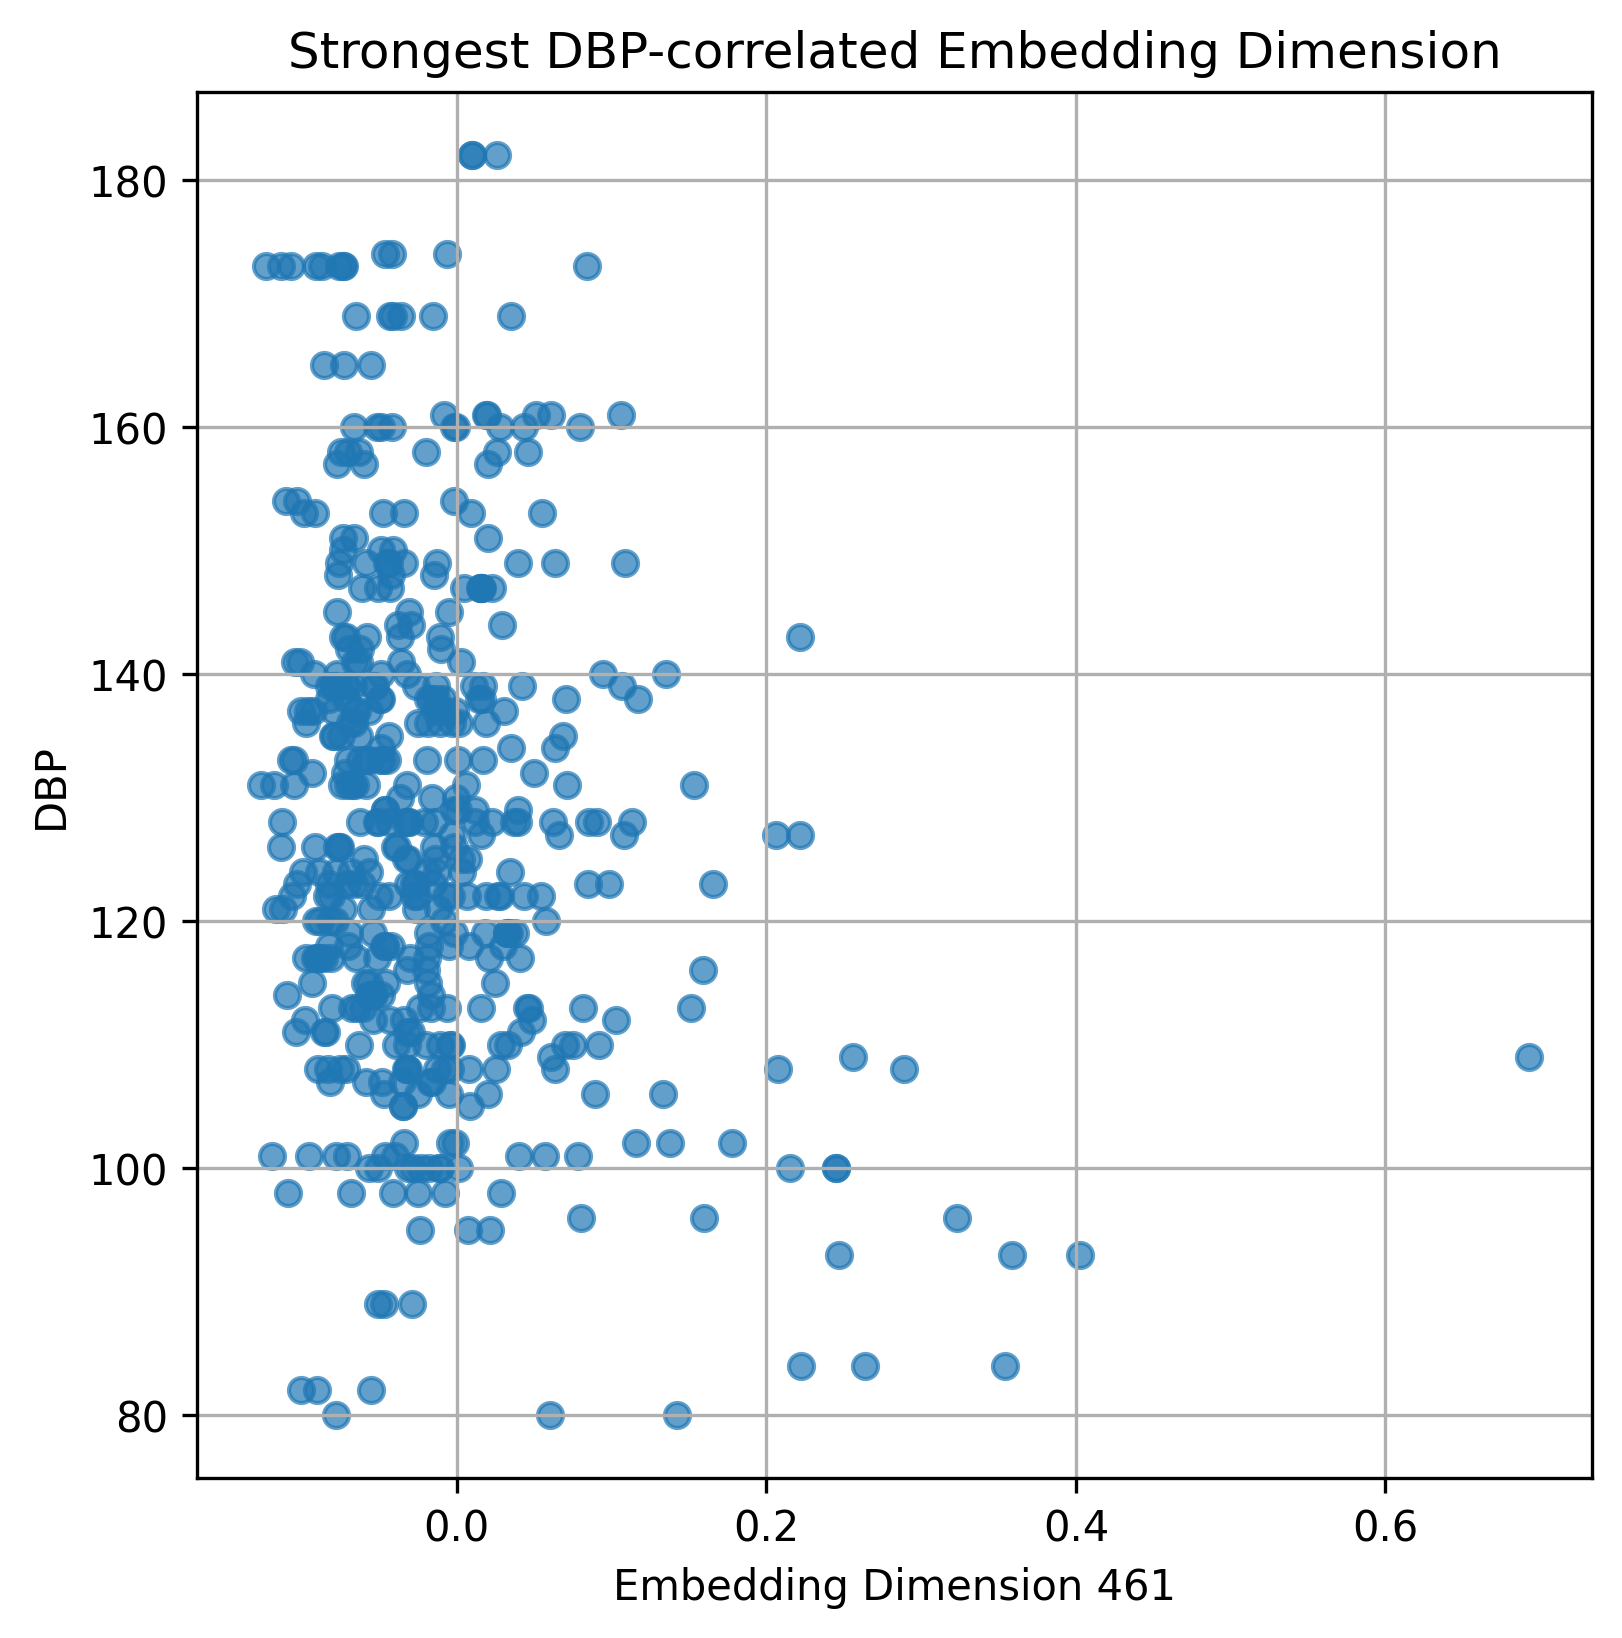

In [ ]:
best = np.argmax(np.abs(dbp_corr))

plt.figure(figsize=(6,6))

plt.scatter(
    embeddings[:, best],
    targets[:,0],
    alpha=0.7
)

plt.xlabel(f"Embedding Dimension {best} values for the recordings")
plt.ylabel("DBP")
plt.title("Strongest DBP-correlated Embedding Dimension")

plt.grid(True)

plt.savefig(
    "best_dbp_dimension.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

display(Image("best_dbp_dimension.png"))

## Doing PCA and then checking the correlation ##

In [42]:
from sklearn.decomposition import PCA

pca = PCA()

embeddings_pca = pca.fit_transform(embeddings)

print("Original shape :", embeddings.shape)
print("PCA shape      :", embeddings_pca.shape)

Original shape : (459, 512)
PCA shape      : (459, 459)


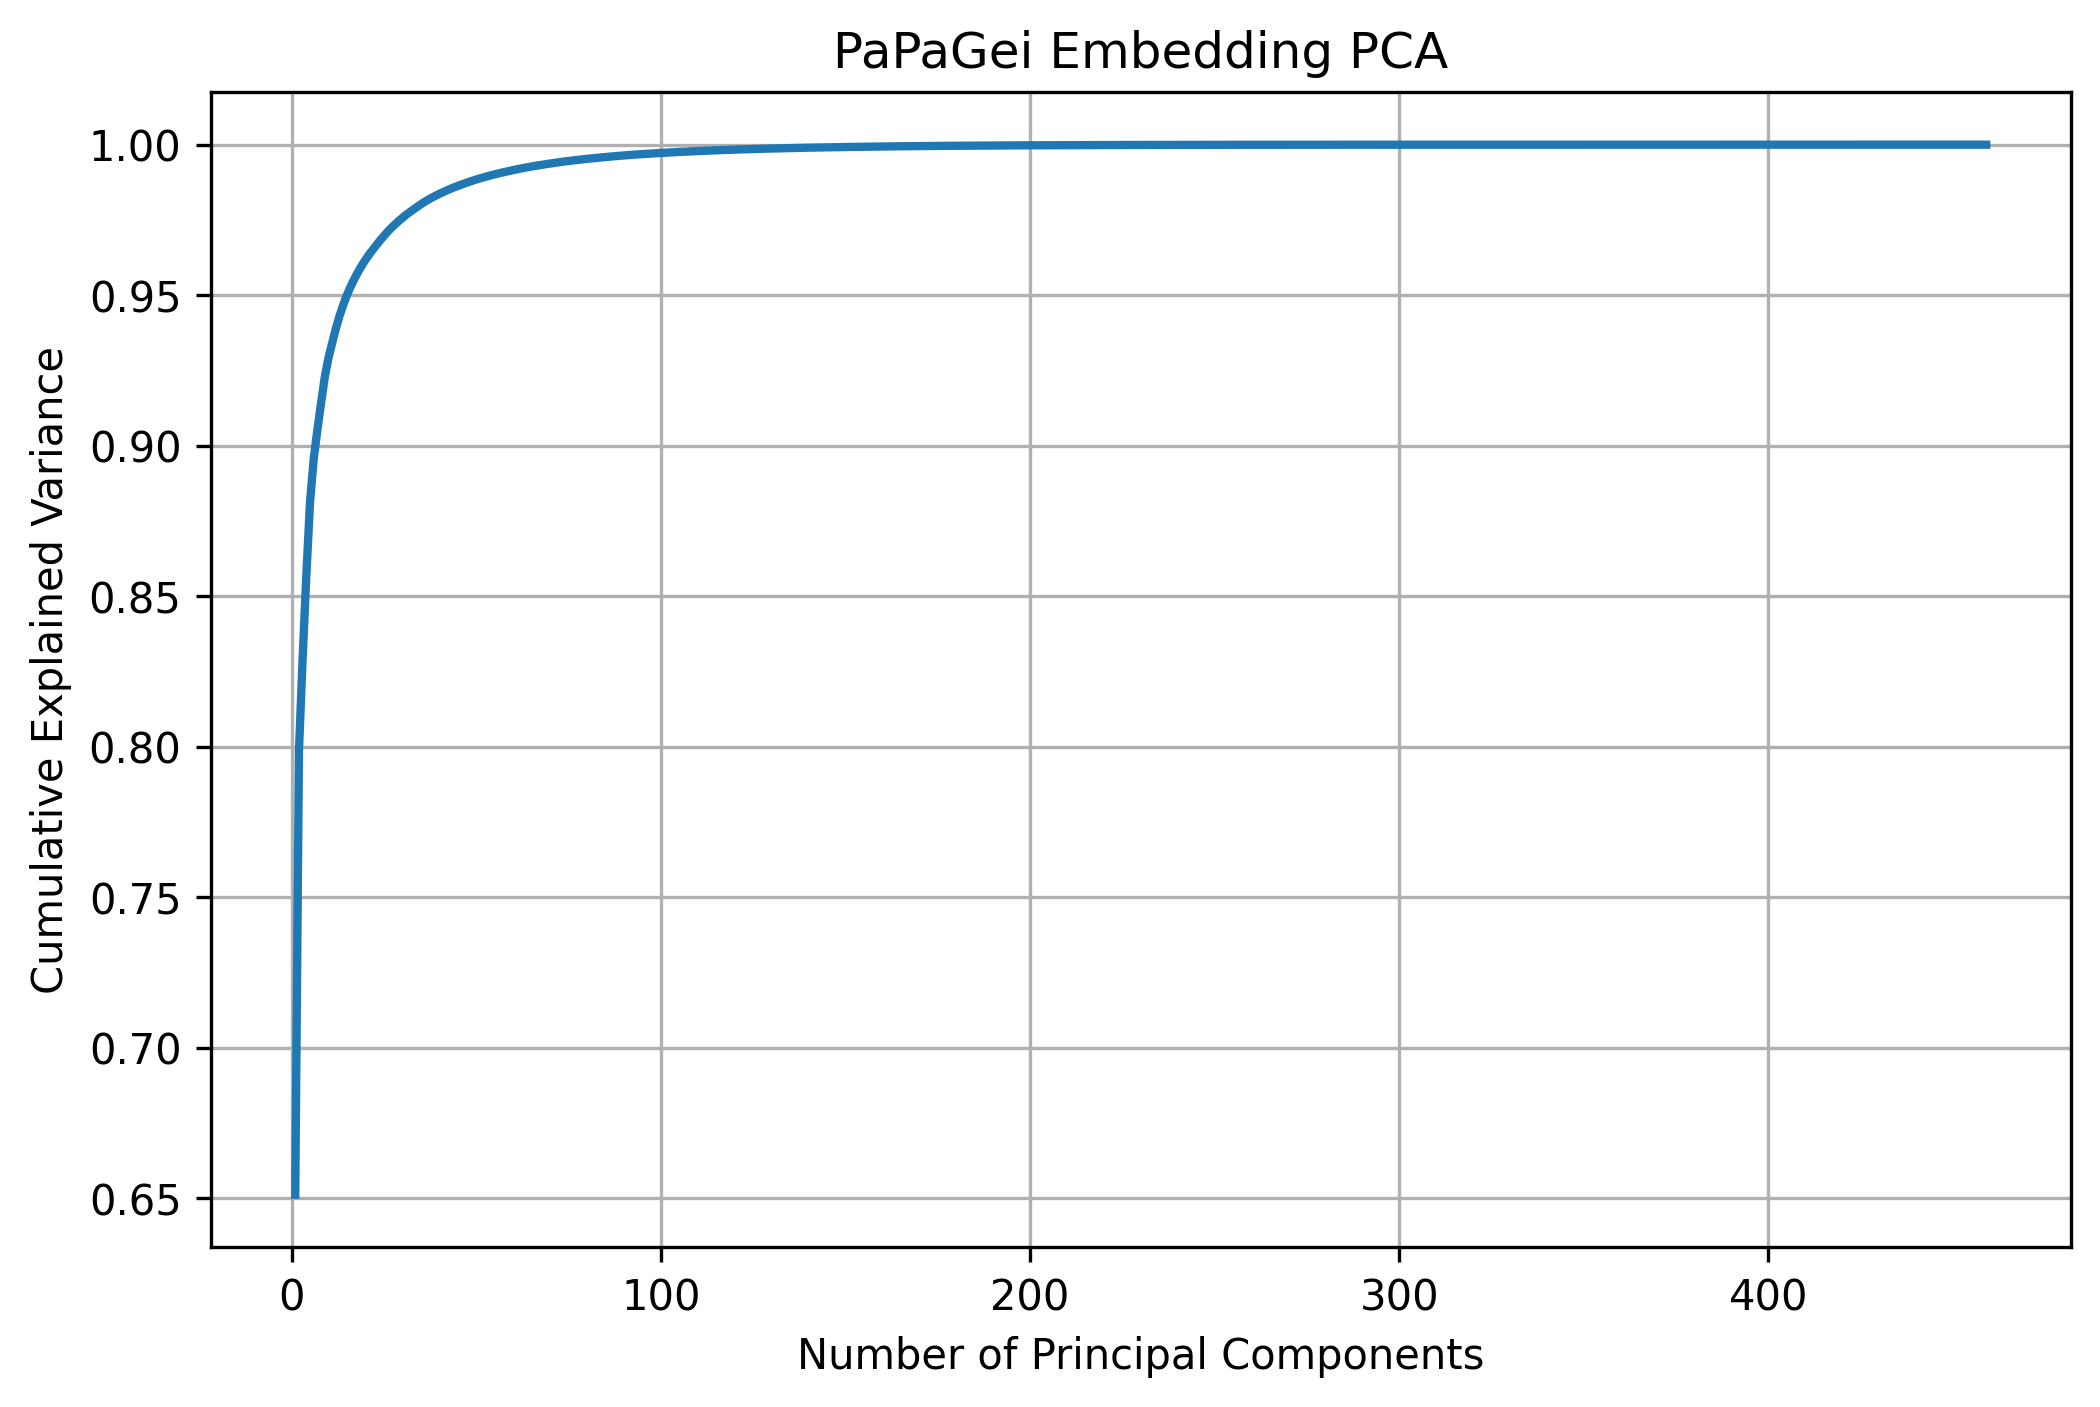

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    linewidth=2
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PaPaGei Embedding PCA")

plt.grid(True)

plt.savefig(
    "pca_variance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

display(Image("pca_variance.png"))

## Variance doesn't mean BP information ##

PCs 1–20 explain 95% of the variance,
but BP prediction continues improving until 80 or 100 PCs

## METHOD 2 ##

Fine - tuning the last layers of PaPaGei

In [34]:
for param in model.encoder.parameters():
    param.requires_grad = False

In [35]:
for block in model.encoder.basicblock_list[-3:]:
    for param in block.parameters():
        param.requires_grad = True

In [36]:
for param in model.encoder.gating_network_1.parameters():
    param.requires_grad = True

for param in model.encoder.gating_network_2.parameters():
    param.requires_grad = True

In [37]:
for param in model.regressor.parameters():
    param.requires_grad = True

In [38]:
trainable = 0
total = 0

print("Trainable parameters:\n")

for name, param in model.named_parameters():

    total += param.numel()

    if param.requires_grad:
        print(name)
        trainable += param.numel()

print("\nTotal parameters :", total)
print("Trainable parameters :", trainable)
print(f"Percentage trainable: {100*trainable/total:.2f}%")

Trainable parameters:

encoder.basicblock_list.15.bn1.weight
encoder.basicblock_list.15.bn1.bias
encoder.basicblock_list.15.conv1.conv.weight
encoder.basicblock_list.15.conv1.conv.bias
encoder.basicblock_list.15.bn2.weight
encoder.basicblock_list.15.bn2.bias
encoder.basicblock_list.15.conv2.conv.weight
encoder.basicblock_list.15.conv2.conv.bias
encoder.basicblock_list.16.bn1.weight
encoder.basicblock_list.16.bn1.bias
encoder.basicblock_list.16.conv1.conv.weight
encoder.basicblock_list.16.conv1.conv.bias
encoder.basicblock_list.16.bn2.weight
encoder.basicblock_list.16.bn2.bias
encoder.basicblock_list.16.conv2.conv.weight
encoder.basicblock_list.16.conv2.conv.bias
encoder.basicblock_list.17.bn1.weight
encoder.basicblock_list.17.bn1.bias
encoder.basicblock_list.17.conv1.conv.weight
encoder.basicblock_list.17.conv1.conv.bias
encoder.basicblock_list.17.bn2.weight
encoder.basicblock_list.17.bn2.bias
encoder.basicblock_list.17.conv2.conv.weight
encoder.basicblock_list.17.conv2.conv.bias
encod

In [39]:
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-6,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [40]:
epochs = 100

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(epochs):

    ############################
    # Training
    ############################

    model.train()

    running_loss = 0.0

    for signals, targets in train_loader:

        signals = signals.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(signals)

        loss = criterion(outputs, targets)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    ############################
    # Validation
    ############################

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for signals, targets in val_loader:

            signals = signals.to(device)
            targets = targets.to(device)

            outputs = model(signals)

            loss = criterion(outputs, targets)

            running_loss += loss.item()

    val_loss = running_loss / len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(model.state_dict(), "best_papagei_finetuned.pt")

print("\nTraining Finished!")

Epoch 01/100 | Train Loss: 79.4746 | Val Loss: 81.4624
Epoch 02/100 | Train Loss: 79.2292 | Val Loss: 81.5312
Epoch 03/100 | Train Loss: 78.1747 | Val Loss: 81.4609
Epoch 04/100 | Train Loss: 77.6235 | Val Loss: 80.6961
Epoch 05/100 | Train Loss: 77.7628 | Val Loss: 80.0736
Epoch 06/100 | Train Loss: 77.3802 | Val Loss: 79.8541
Epoch 07/100 | Train Loss: 77.1602 | Val Loss: 79.7938
Epoch 08/100 | Train Loss: 77.0558 | Val Loss: 79.3274
Epoch 09/100 | Train Loss: 75.9511 | Val Loss: 78.5304
Epoch 10/100 | Train Loss: 75.9672 | Val Loss: 78.0350
Epoch 11/100 | Train Loss: 75.1835 | Val Loss: 77.6005
Epoch 12/100 | Train Loss: 74.3586 | Val Loss: 76.8062
Epoch 13/100 | Train Loss: 73.9488 | Val Loss: 75.8789
Epoch 14/100 | Train Loss: 73.3756 | Val Loss: 75.6902
Epoch 15/100 | Train Loss: 73.0674 | Val Loss: 76.2124
Epoch 16/100 | Train Loss: 72.4602 | Val Loss: 74.8518
Epoch 17/100 | Train Loss: 72.8360 | Val Loss: 74.6217
Epoch 18/100 | Train Loss: 71.3005 | Val Loss: 73.6462
Epoch 19/1

In [41]:
model.load_state_dict(torch.load("best_papagei_finetuned.pt"))
model.eval()

BPModel(
  (encoder): ResNet1DMoE(
    (first_block_conv): MyConv1dPadSame(
      (conv): Conv1d(1, 32, kernel_size=(3,), stride=(1,))
    )
    (first_block_bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (first_block_relu): ReLU()
    (basicblock_list): ModuleList(
      (0): BasicBlock(
        (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU()
        (do1): Dropout(p=0.5, inplace=False)
        (conv1): MyConv1dPadSame(
          (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
        )
        (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU()
        (do2): Dropout(p=0.5, inplace=False)
        (conv2): MyConv1dPadSame(
          (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
        )
        (max_pool): MyMaxPool1dPadSame(
          (max_pool): MaxPool1d(kernel_size=1, stri

In [42]:
test_loss = 0.0

all_preds = []
all_targets = []

with torch.no_grad():

    for signals, targets in test_loader:

        signals = signals.to(device)
        targets = targets.to(device)

        outputs = model(signals)

        loss = criterion(outputs, targets)

        test_loss += loss.item()

        all_preds.append(outputs.cpu())
        all_targets.append(targets.cpu())


test_loss = test_loss / len(test_loader)

print(f"Test Loss: {test_loss:.4f}")

Test Loss: 31.5165


In [43]:
print("Final Train Loss:", train_losses[-1])
print("Final Val Loss:", val_losses[-1])
print("Test Loss:", test_loss)

Final Train Loss: 31.45823554992676
Final Val Loss: 29.68433427810669
Test Loss: 31.516451358795166


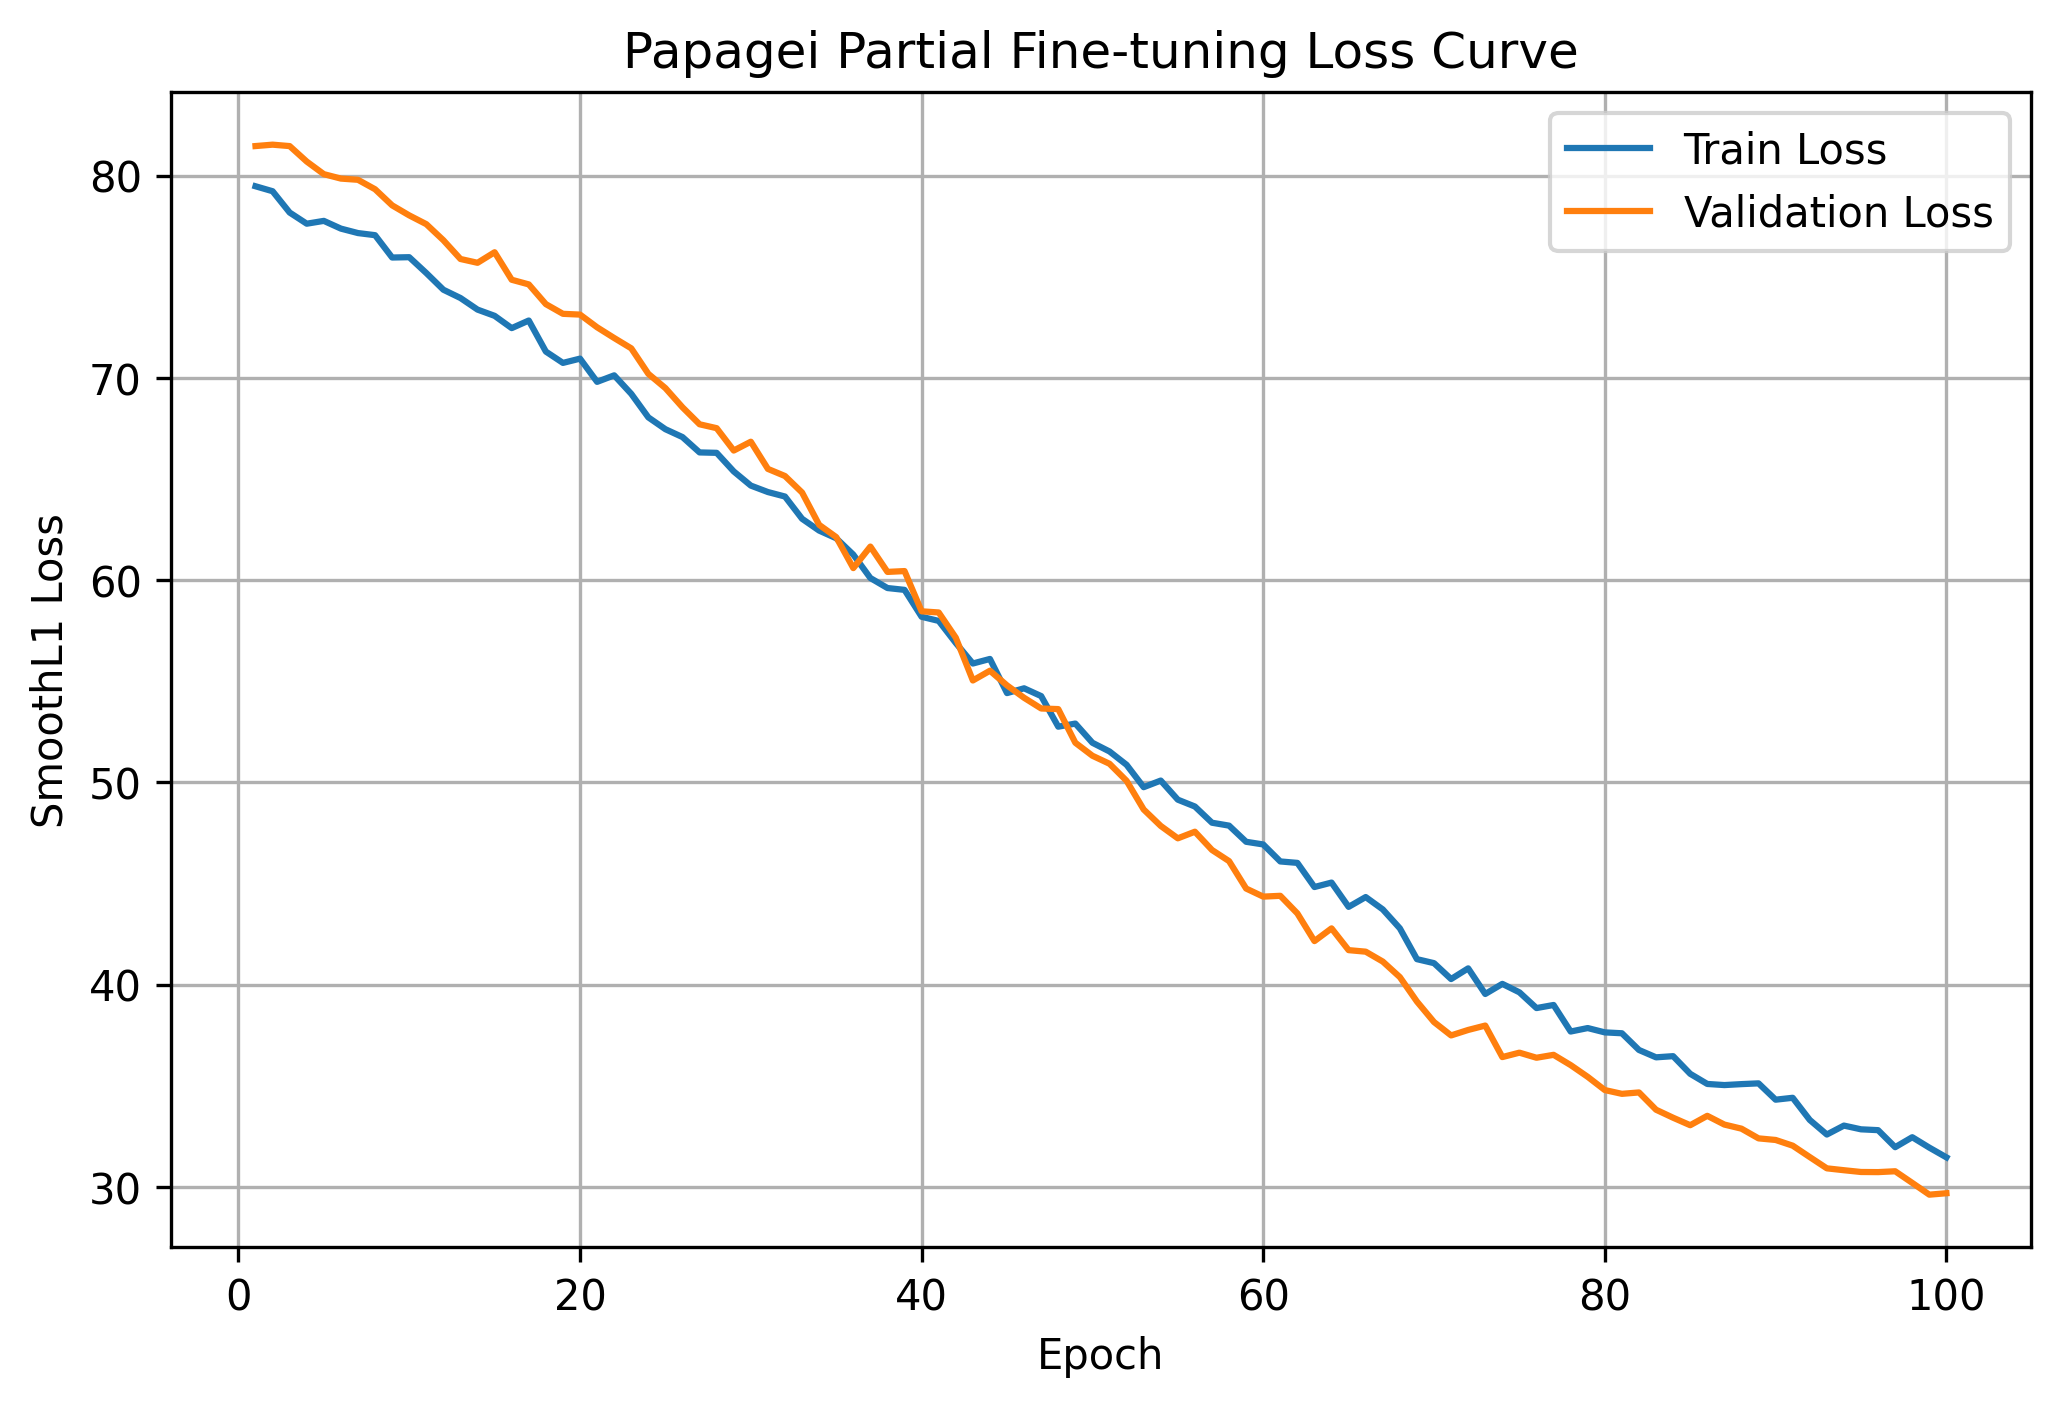

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, epochs+1),
    train_losses,
    label="Train Loss"
)

plt.plot(
    range(1, epochs+1),
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("SmoothL1 Loss")
plt.title("Papagei Partial Fine-tuning Loss Curve")

plt.legend()
plt.grid(True)

plt.savefig(
    "papagei_finetuning_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

display(Image(filename="papagei_finetuning_loss.png"))

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

preds = torch.cat(all_preds).numpy()
targets = torch.cat(all_targets).numpy()

sbp_mae = mean_absolute_error(
    targets[:,0],
    preds[:,0]
)

dbp_mae = mean_absolute_error(
    targets[:,1],
    preds[:,1]
)

sbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,0],
        preds[:,0]
    )
)

dbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,1],
        preds[:,1]
    )
)

print("SBP MAE:", sbp_mae)
print("DBP MAE:", dbp_mae)

print("SBP RMSE:", sbp_rmse)
print("DBP RMSE:", dbp_rmse)

SBP MAE: 53.750744
DBP MAE: 10.739534
SBP RMSE: 58.01799
DBP RMSE: 13.060575


In [46]:
# print(test_loss)

# print("Predictions:")
# print(preds[:10])

# print("Targets:")
# print(targets[:10])